In [73]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import random
import logging as logger
from torch import nn
from typing import List

SRC_PATH = Path.cwd().parent / 'src'
DATA_PATH = Path.cwd().parent / 'data'
CONFIG_PATH = Path.cwd().parent / 'config'
sys.path.insert(0, str(SRC_PATH))
sys.path.insert(0, str(CONFIG_PATH))
sys.path.insert(0, str(DATA_PATH))

print(f"Adding to path: {SRC_PATH}")
print(f"Path exists: {SRC_PATH.exists()}")

from plotting import DataPlotter
plotter = DataPlotter()

from evaluate import HiggsEvaluator

from utils import load_model_checkpoint

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Adding to path: /home/moh/ws_idea/Higgs Boson Detection/src
Path exists: True


In [90]:
class HiggsModel(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims: List[int]):
        super(HiggsModel, self).__init__()
        fc1 = nn.Linear(input_dim, hidden_dims[0])
        layers = [fc1]
        for i in range(len(hidden_dims) - 1):
            layers.append(nn.Linear(hidden_dims[i], hidden_dims[i + 1]))
            layers.append(nn.BatchNorm1d(hidden_dims[i + 1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=0.5))

        last_fc = nn.Linear(hidden_dims[-1], output_dim)
        layers.append(last_fc)

        self.seq = nn.Sequential(*layers)

    def forward(self, x):
        return self.seq(x)
    
    def predict(self, X , device='cpu'):
        self.eval()
        with torch.inference_mode():
            inputs = torch.tensor(X, dtype=torch.float32).to(device)
            outputs = self.forward(inputs)
            probs = torch.softmax(outputs, dim=1).argmax(dim=1)
        return probs.cpu().numpy() 

In [ ]:
def create_XGBoost_model(scale_pos_weight=None, random_state=42):
    from xgboost import XGBClassifier
    model = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=random_state
    )
    return model

In [ ]:
from sklearn.metrics import roc_auc_score, brier_score_loss
from utils import save_model_checkpoint, load_model_checkpoint
from tqdm.auto import tqdm

# use accuracy_score for evaluation,
# because the dataset is balanced and we want a simple metric to track during training.

class HiggsTraining:
    def __init__(self, model, criterion, optimizer, device,):
        self.model = model.to(device)
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device


    def train_step(self, dataloader):
        self.model.train()
        total_loss = 0.0
        
        for inputs, labels in dataloader:    
            inputs, labels = inputs.to(self.device), labels.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = self.criterion(outputs, labels.squeeze())
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()        
        total_loss /= len(dataloader)

        return total_loss


    @torch.inference_mode()    
    def validate_step(self, dataloader):
    
        roc_auc = 0.0
        bsl = float('inf')
        loss = 0.0
        all_labels = []
        all_probs = []
        self.model.eval()
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(self.device), labels.to(self.device)
            outputs = self.model(inputs)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, dim=1).argmax(dim=1).cpu().numpy())
            loss += self.criterion(outputs, labels.squeeze()).item()

        loss = loss / len(dataloader)
        roc_auc = roc_auc_score(all_labels, all_probs)
        bsl = brier_score_loss(all_labels, all_probs)
        return loss, roc_auc, bsl

    @torch.inference_mode()  
    def test_step(self, dataloader):
        self.model.eval()

        loss = 0.0
        roc_auc = 0.0
        bsl = float('inf')
        all_labels = []
        all_probs = []
        
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(self.device), labels.to(self.device)
            outputs = self.model(inputs)
            loss += self.criterion(outputs, labels.squeeze())
            
            probs = torch.softmax(outputs, dim=1).argmax(dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
        
        loss = loss / len(dataloader)
        roc_auc = roc_auc_score(all_labels, all_probs)
        bsl = brier_score_loss(all_labels, all_probs)
        return loss.item(), roc_auc, bsl, all_labels, all_probs  
    
    def fit(self, train_loader, val_loader, epochs, checkpoint_path=None):
        
        loss_history = {
            "train_loss": [],
            "val_loss": [],
            "val_roc_auc": [],
            "val_brier_score": []
        }

        max_roc_auc = 0.0

        for epoch in tqdm(range(epochs), desc="Training Progress"):
            train_loss = self.train_step(train_loader)
            val_loss, val_roc_auc, val_brier_score = self.validate_step(val_loader)
            loss_history["train_loss"].append(train_loss)
            loss_history["val_loss"].append(val_loss)
            loss_history["val_roc_auc"].append(val_roc_auc)
            loss_history["val_brier_score"].append(val_brier_score)

            if val_roc_auc > max_roc_auc and checkpoint_path:
                max_roc_auc = val_roc_auc
                save_model_checkpoint(self.model, self.optimizer, epoch, loss_history, f"{checkpoint_path}/best_model.pt")
            if epoch % 10 == 0:
                logger.info(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val ROC AUC: {val_roc_auc:.4f}, Val Brier Score: {val_brier_score:.4f}")
        return loss_history

/home/moh/ws_idea/Higgs Boson Detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [102]:
CONFIG = {
    'seed': 42,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    
    'test_size': 0.1,  
    'val_size': 0.1, 
    
    # Model architecture
    'hidden_sizes': [500, 300, 200, 100, 50],
    'dropout_rate': 0.2,
    'output_dim': 2,
    'input_dim': 28,
    
    # Training
    'batch_size': 1024,  
    'learning_rate': 1e-3,
    'l2_reg': 1e-6,       # Weight decay (weak L2)
    'epochs': 100,
    'early_stopping_patience': 15,
    
    # Data paths
    'data_dir': '../data/processed/higgs-uci-dataset',
    'checkpoint_dir': '../results/models/',
    'plot_dir': '../results/plots/',
    'evaluation_dir': '../results/evaluation/'
}

In [80]:
def create_nn_model(input_dim, config):
    model = HiggsModel(input_dim=input_dim, output_dim=config['output_dim'], hidden_dims=config['hidden_sizes'])
    model = model.to(config['device'])
    return model

In [ ]:
higgs_model = create_nn_model(input_dim=28, config=CONFIG)

In [7]:
X_train = pd.read_csv(f"{CONFIG['data_dir']}/train/train_dataset.csv").values
y_train = pd.read_csv(f"{CONFIG['data_dir']}/train/train_labels.csv").values
X_val = pd.read_csv(f"{CONFIG['data_dir']}/val/val_dataset.csv").values
y_val = pd.read_csv(f"{CONFIG['data_dir']}/val/val_labels.csv").values
X_test = pd.read_csv(f"{CONFIG['data_dir']}/test/test_dataset.csv").values
y_test = pd.read_csv(f"{CONFIG['data_dir']}/test/test_labels.csv").values

In [8]:
def create_random_sample(X, y, sample_size=10000):
    indices = np.random.choice(len(X), size=sample_size, replace=False)
    return X[indices], y[indices]

X_train_sampled, y_train_sampled = create_random_sample(X_train, y_train, sample_size=88000)
X_val_sampled, y_val_sampled = create_random_sample(X_val, y_val, sample_size=10000)
X_test_sampled, y_test_sampled = create_random_sample(X_test, y_test, sample_size=10000)

In [9]:
from torch.utils.data import DataLoader 

from data import HIGGSDataset

train_dataset = HIGGSDataset(X_train_sampled, y_train_sampled)
test_dataset = HIGGSDataset(X_test_sampled, y_test_sampled)
val_dataset = HIGGSDataset(X_val_sampled, y_val_sampled)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

In [205]:
hg_training = HiggsTraining(
    model=higgs_model,
    criterion=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(higgs_model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['l2_reg']),
    device=CONFIG['device']
)

In [206]:
loss_history = hg_training.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=CONFIG['epochs'],
    checkpoint_path=CONFIG['checkpoint_dir']
)

Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:root:Model checkpoint saved at ../results/models//best_model.pt
INFO:root:Epoch 1/100 - Train Loss: 0.5851, Val Loss: 0.5551, Val ROC AUC: 0.7172, Val Brier Score: 0.2816
Training Progress: 100%|██████████| 100/100 [16:24<00:00,  9.84s/it]


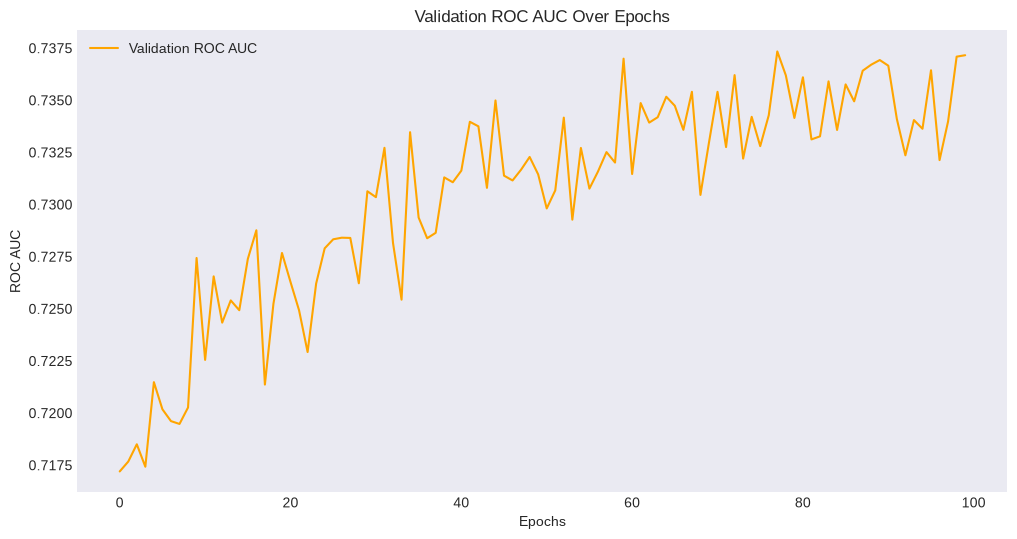

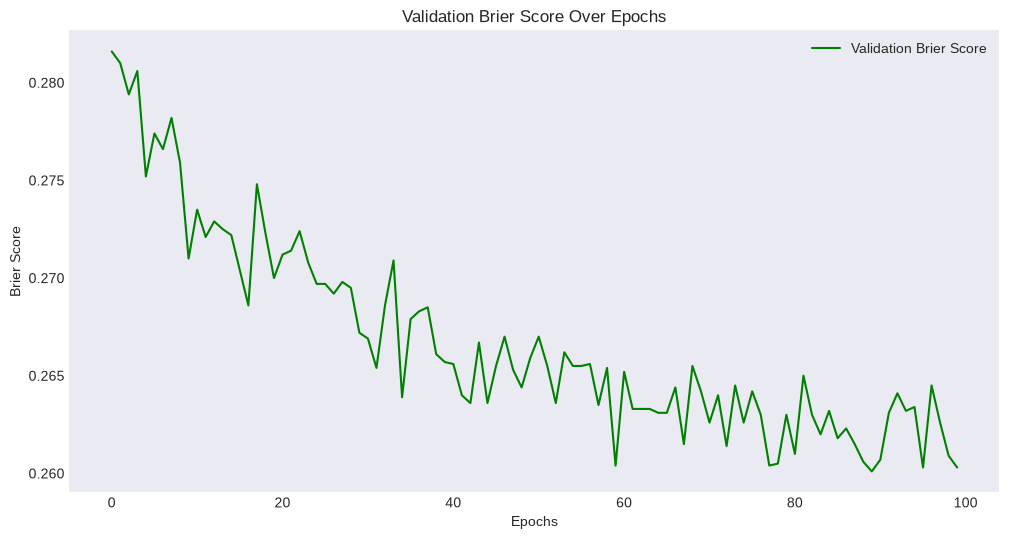

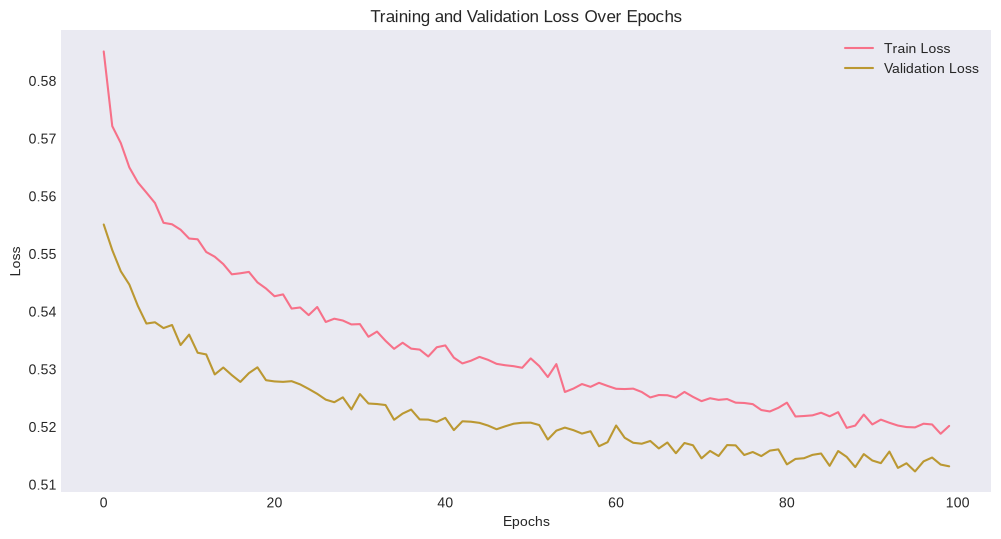

In [ ]:
def plot_loss_history(loss_history):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history['train_loss'], label='Train Loss')
    plt.plot(loss_history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid()
    plt.show()

def plot_roc_auc_history(loss_history):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history['val_roc_auc'], label='Validation ROC AUC', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('ROC AUC')
    plt.title('Validation ROC AUC Over Epochs')
    plt.legend()
    plt.grid()
    plt.show()

def plot_brier_score_history(loss_history):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history['val_brier_score'], label='Validation Brier Score', color='green')
    plt.xlabel('Epochs')
    plt.ylabel('Brier Score')
    plt.title('Validation Brier Score Over Epochs')
    plt.legend()
    plt.grid()
    plt.show()


In [ ]:
plot_roc_auc_history(loss_history)
plot_brier_score_history(loss_history)
plot_loss_history(loss_history)

In [91]:
higgs_model = create_nn_model(input_dim=28, config=CONFIG)
optimizer = torch.optim.Adam(higgs_model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['l2_reg'])
higgs_model, optimizer, start_epoch, loss_history = load_model_checkpoint(higgs_model, optimizer, f"{CONFIG['checkpoint_dir']}/best_model.pt", device=CONFIG['device'])


INFO:root:Model checkpoint loaded from ../results/models//best_model.pt at epoch 77


In [92]:
test_preds_nn_model = higgs_model.predict(X_test_sampled, device=CONFIG['device'])

In [104]:
import pprint
nn_model_evaluator = HiggsEvaluator(y_test_sampled.squeeze(), test_preds_nn_model, "Neural Network")
print("Neural Network Evaluation:")

evaluation_results = nn_model_evaluator.evaluate()
if not Path(CONFIG['evaluation_dir']).exists():
    Path(CONFIG['evaluation_dir']).mkdir(parents=True, exist_ok=True)
nn_model_evaluator.save_evaluation_results(evaluation_results, f"{CONFIG['evaluation_dir']}/nn_model_evaluation_results.json")
pprint.pprint(evaluation_results)

INFO:evaluate:Neural Network Optimal AMS: 59.3617 at threshold 0.001
INFO:evaluate:Saved evaluation results to ../results/evaluation//nn_model_evaluation_results.json


Neural Network Evaluation:
{'accuracy': 0.7438,
 'ams_at_optimal': 59.36170812290533,
 'auc': 0.7417328357901984,
 'brier_score': 0.2562,
 'f1_score': 0.7637838834593399,
 'false_negative_rate': 0.2319673651029112,
 'false_positive_rate': 0.284566963316692,
 'fn': 1251,
 'fp': 1311,
 'log_loss': 9.234383998291815,
 'matthews_corrcoef': 0.48396029503506705,
 'model': 'Neural Network',
 'optimal_threshold': 0.001,
 'precision': 0.759581881533101,
 'recall': 0.7680326348970888,
 'sensitivity': 0.7680326348970888,
 'specificity': 0.715433036683308,
 'tn': 3296,
 'total_samples': 10000,
 'tp': 4142}


In [ ]:
xgboost_model = create_XGBoost_model()
xgboost_model.fit(X_train_sampled, y_train_sampled)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [66]:
import pprint
test_preds_xgb = xgboost_model.predict_proba(X_test_sampled)[:, 1]
pprint.pprint(test_preds_xgb)

array([0.23280375, 0.51726234, 0.7536543 , ..., 0.45176974, 0.50277406,
       0.2530728 ], shape=(10000,), dtype=float32)


In [105]:
xgb_evaluator = HiggsEvaluator(y_test_sampled.squeeze(), test_preds_xgb, "XGBoost")
print("XGBoost Evaluation:")

xgb_evaluation_results = xgb_evaluator.evaluate()
if not Path(CONFIG['evaluation_dir']).exists():
    Path(CONFIG['evaluation_dir']).mkdir(parents=True, exist_ok=True)
xgb_evaluator.save_evaluation_results(xgb_evaluation_results, f"{CONFIG['evaluation_dir']}/xgb_evaluation_results.json")
pprint.pprint(xgb_evaluation_results)

INFO:evaluate:XGBoost Optimal AMS: 72.3111 at threshold 0.788
INFO:evaluate:Saved evaluation results to ../results/evaluation//xgb_evaluation_results.json


XGBoost Evaluation:
{'accuracy': 0.6201,
 'ams_at_optimal': 72.31107288652295,
 'auc': 0.8094430065165389,
 'brier_score': 0.17811934649944305,
 'f1_score': 0.4798028207585924,
 'false_negative_rate': 0.6751344335249397,
 'false_positive_rate': 0.034295637074017796,
 'fn': 3641,
 'fp': 158,
 'log_loss': 0.5300871729850769,
 'matthews_corrcoef': 0.36845464822137164,
 'model': 'XGBoost',
 'optimal_threshold': 0.788,
 'precision': 0.9172774869109948,
 'recall': 0.32486556647506026,
 'sensitivity': 0.32486556647506026,
 'specificity': 0.9657043629259822,
 'tn': 4449,
 'total_samples': 10000,
 'tp': 1752}
